In [10]:
import pandas as pd
import numpy as np

In [7]:
path = "../data/keystroke_dynamics-dataset/DSL-StrongPasswordData.csv"
df = pd.read_csv(path)

print("shape:", df.shape)
print("\nfirst 15 columns:", list(df.columns[:15]))

print("\n#subjects:", df["subject"].nunique())
print("\nrows per subject (top 5):")
print(df["subject"].value_counts().head())

print("\nmissing values (top 10):")
print(df.isna().sum().sort_values(ascending=False).head(10))

df.head()

shape: (20400, 34)

first 15 columns: ['subject', 'sessionIndex', 'rep', 'H.period', 'DD.period.t', 'UD.period.t', 'H.t', 'DD.t.i', 'UD.t.i', 'H.i', 'DD.i.e', 'UD.i.e', 'H.e', 'DD.e.five', 'UD.e.five']

#subjects: 51

rows per subject (top 5):
subject
s002    400
s003    400
s004    400
s005    400
s007    400
Name: count, dtype: int64

missing values (top 10):
subject         0
DD.a.n          0
DD.Shift.r.o    0
UD.Shift.r.o    0
H.o             0
DD.o.a          0
UD.o.a          0
H.a             0
UD.a.n          0
sessionIndex    0
dtype: int64


,subject,sessionIndex,rep,H.period,DD.period.t,UD.period.t,H.t,DD.t.i,UD.t.i,H.i,...,H.a,DD.a.n,UD.a.n,H.n,DD.n.l,UD.n.l,H.l,DD.l.Return,UD.l.Return,H.Return
0,s002,1,1,0.1491,0.3979,0.2488,0.1069,0.1674,0.0605,0.1169,...,0.1349,0.1484,0.0135,0.0932,0.3515,0.2583,0.1338,0.3509,0.2171,0.0742
1,s002,1,2,0.1111,0.3451,0.2340,0.0694,0.1283,0.0589,0.0908,...,0.1412,0.2558,0.1146,0.1146,0.2642,0.1496,0.0839,0.2756,0.1917,0.0747
2,s002,1,3,0.1328,0.2072,0.0744,0.0731,0.1291,0.0560,0.0821,...,0.1621,0.2332,0.0711,0.1172,0.2705,0.1533,0.1085,0.2847,0.1762,0.0945
3,s002,1,4,0.1291,0.2515,0.1224,0.1059,0.2495,0.1436,0.1040,...,0.1457,0.1629,0.0172,0.0866,0.2341,0.1475,0.0845,0.3232,0.2387,0.0813
4,s002,1,5,0.1249,0.2317,0.1068,0.0895,0.1676,0.0781,0.0903,...,0.1312,0.1582,0.0270,0.0884,0.2517,0.1633,0.0903,0.2517,0.1614,0.0818


The dataset contains 20,400 samples from 51 users, with each user contributing 400 password entry attempts. Each row represents a single login attempt and includes three metadata columns (subject, sessionIndex, rep) and 31 keystroke timing features capturing dwell times and inter-key latencies. The dataset is balanced across users and contains no missing values

## Train/Test Split
Split the dataset by session to better simulate real-world authentication scenarios. Earlier sessions are used for training, later sessions are reserved for testing.

In [12]:
session_col = "sessionIndex"

train_idx = []
test_idx = []

for user, g in df.groupby("subject"):
    
    sessions = np.sort(g[session_col].unique())
    
    # early 80% session as train
    cutoff = int(len(sessions) * 0.8)
    
    train_sessions = sessions[:cutoff]
    test_sessions = sessions[cutoff:]
    
    train_idx.extend(g[g[session_col].isin(train_sessions)].index)
    test_idx.extend(g[g[session_col].isin(test_sessions)].index)

train_df = df.loc[train_idx].reset_index(drop=True)
test_df = df.loc[test_idx].reset_index(drop=True)

print("Train size:", train_df.shape)
print("Test size:", test_df.shape)

print("\nTrain sessions:", sorted(train_df[session_col].unique()))
print("Test sessions:", sorted(test_df[session_col].unique()))

Train size: (15300, 34)
Test size: (5100, 34)

Train sessions: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Test sessions: [np.int64(7), np.int64(8)]


## Features
Construct the feature matrix X using the keystroke timing features and use subject as the label y. Metadata columns (subject, sessionIndex, rep) are excluded from the feature set. The features are then standardized using StandardScaler to ensure all timing variables are on a comparable scale.

In [16]:
from sklearn.preprocessing import StandardScaler

# metadata columns
meta_cols = ["subject", "sessionIndex", "rep"]

# feature columns
feature_cols = [c for c in train_df.columns if c not in meta_cols]

# construct X and y
X_train = train_df[feature_cols].values
X_test = test_df[feature_cols].values

y_train = train_df["subject"].values
y_test = test_df["subject"].values

print("Feature dimension:", X_train.shape[1])

# standardize
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Train feature shape:", X_train.shape)
print("Test feature shape:", X_test.shape)

Feature dimension: 31
Train feature shape: (15300, 31)
Test feature shape: (5100, 31)


## Baseline LinearSVC
Train a baseline classifier to evaluate whether keystroke timing patterns can reliably distinguish between users. Use a linear Support Vector Machine (SVM) to perform multi-class classification, where the model predicts the user identity from the standardized keystroke timing features.

In [19]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

# train model
model = LinearSVC()

model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)

# evaluate
acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7464705882352941

Classification Report:
              precision    recall  f1-score   support

        s002       0.69      0.34      0.46       100
        s003       0.46      0.52      0.49       100
        s004       0.72      0.81      0.76       100
        s005       0.80      0.75      0.77       100
        s007       0.72      0.49      0.58       100
        s008       0.63      0.44      0.52       100
        s010       0.81      0.83      0.82       100
        s011       0.53      0.89      0.66       100
        s012       0.71      0.79      0.75       100
        s013       0.67      0.82      0.74       100
        s015       0.62      0.40      0.49       100
        s016       0.62      0.33      0.43       100
        s017       0.90      0.93      0.92       100
        s018       0.57      0.78      0.66       100
        s019       0.80      0.88      0.84       100
        s020       0.73      0.67      0.70       100
        s021       0.62     

Keystroke dynamics contain strong user-specific behavioral signals.

## PCA embedding
Use PCA to obtain a compact embedding of keystroke timing features

In [28]:
from sklearn.decomposition import PCA

# choose embedding dimension
k = 16

pca = PCA(n_components=k, random_state=0)
E_train = pca.fit_transform(X_train)
E_test = pca.transform(X_test)

print("E_train shape:", E_train.shape)
print("E_test shape:", E_test.shape)

print("Explained variance ratio (sum):", pca.explained_variance_ratio_.sum())
print("First 10 explained variance ratios:", np.round(pca.explained_variance_ratio_[:10], 4))

E_train shape: (15300, 16)
E_test shape: (5100, 16)
Explained variance ratio (sum): 0.9425092561011021
First 10 explained variance ratios: [0.2595 0.1687 0.0606 0.0578 0.0529 0.0472 0.0442 0.0418 0.0397 0.0352]


To evaluate whether the learned embeddings capture user-specific structure, we compare distances between samples from the same user (intra-user distances) and samples from different users (inter-user distances). A useful behavioral embedding should produce smaller distances for the same user and larger distances for different users.

In [31]:
from sklearn.metrics import pairwise_distances

# randomly sample to keep computation reasonable
np.random.seed(0)

sample_size = 2000
idx = np.random.choice(len(E_test), sample_size, replace=False)

E_sample = E_test[idx]
y_sample = y_test[idx]

# compute pairwise distances
D = pairwise_distances(E_sample)

intra = []
inter = []

for i in range(sample_size):
    for j in range(i+1, sample_size):
        if y_sample[i] == y_sample[j]:
            intra.append(D[i,j])
        else:
            inter.append(D[i,j])

print("Intra-user mean distance:", np.mean(intra))
print("Inter-user mean distance:", np.mean(inter))

Intra-user mean distance: 3.321534815430899
Inter-user mean distance: 5.9523307683545505


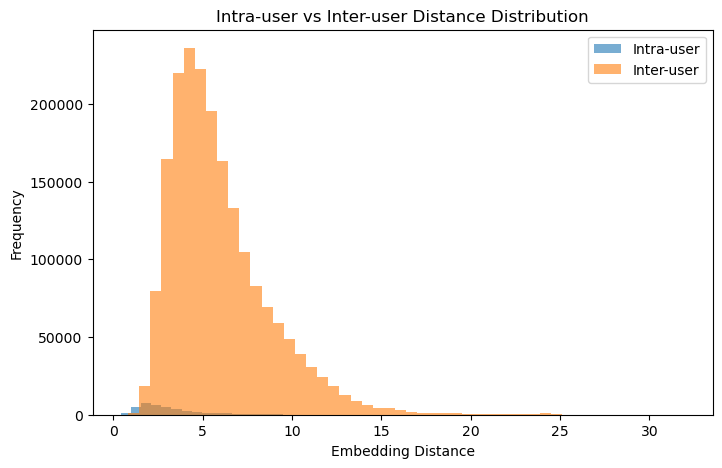

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(intra, bins=50, alpha=0.6, label="Intra-user")
plt.hist(inter, bins=50, alpha=0.6, label="Inter-user")

plt.xlabel("Embedding Distance")
plt.ylabel("Frequency")
plt.title("Intra-user vs Inter-user Distance Distribution")

plt.legend()

plt.show()